# 05 — Evaluation Analysis & Charts

Owner: **Hoàng Đức Kiên** (QA) — Task T10 / T19.

Goals:
- Load CF eval scores (`evaluation/cf_eval_scores.csv` or `reports/cf_eval_scores.csv`)
- Plot HR@10 / NDCG@10
- Spot-check 5 users' recommendations
- Export charts under `reports/charts/`

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
sns.set_theme(style="whitegrid")
CHARTS = ROOT / "reports" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Matplotlib is building the font cache; this may take a moment.


Setup OK


## Load eval scores

In [2]:
candidates = [
    ROOT / "evaluation" / "cf_eval_scores.csv",
    ROOT / "reports" / "cf_eval_scores.csv",
]
csv = next((p for p in candidates if p.exists()), None)
if csv is None:
    raise FileNotFoundError(
        "Run `python scripts/run_evaluation.py` first "
        "(or execute notebook 04 eval sweep)."
    )
df = pd.read_csv(csv)
print("loaded", csv)
df

loaded /Users/macbook/Module 2/evaluation/cf_eval_scores.csv


,users_evaluated,HR@10,NDCG@10,HR@10_all,NDCG@10_all
0,200,0.01,0.007153,0.01,0.007153


## Chart 1 — HR@10 summary

saved /Users/macbook/Module 2/reports/charts/hr_vs_topk.png


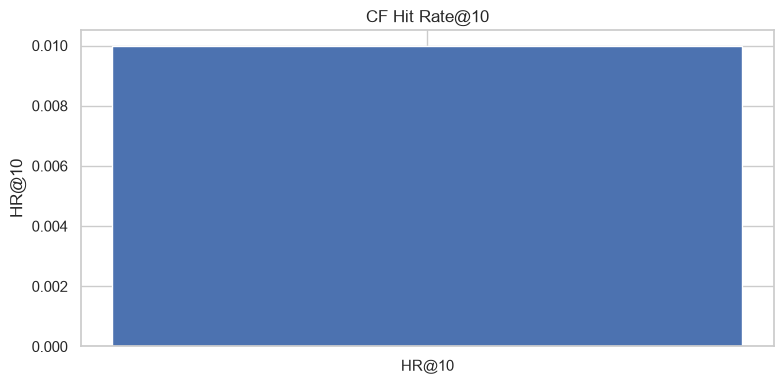

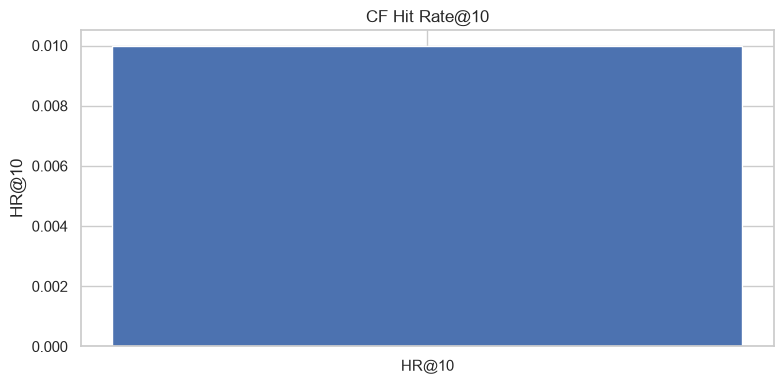

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df.copy()
if "sample" in plot_df.columns:
    sns.barplot(data=plot_df, x="sample", y="HR@10", ax=ax)
    ax.set_xlabel("sample size")
else:
    ax.bar(["HR@10"], [float(plot_df["HR@10"].iloc[0])])
ax.set_title("CF Hit Rate@10")
ax.set_ylabel("HR@10")
plt.tight_layout()
fig.savefig(CHARTS / "hr_vs_topk.png", dpi=120)
print("saved", CHARTS / "hr_vs_topk.png")
fig

## Chart 2 — NDCG@10 summary

saved /Users/macbook/Module 2/reports/charts/ndcg_vs_topk.png


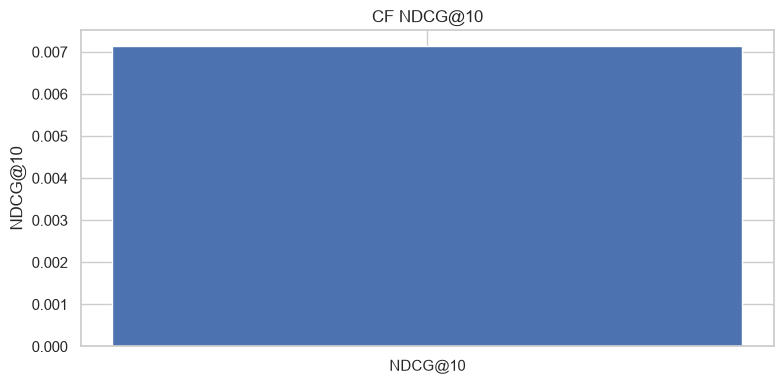

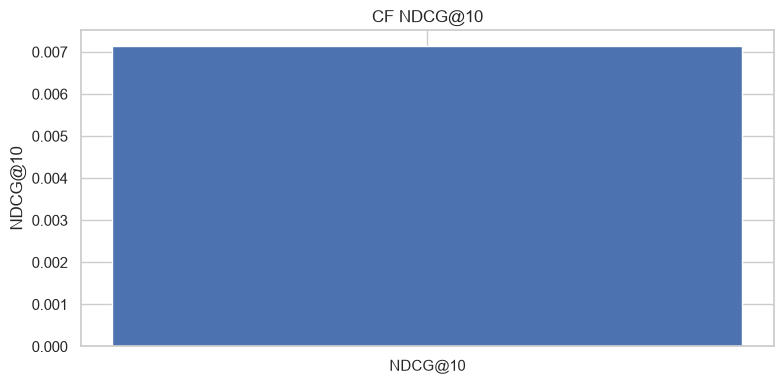

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df.copy()
if "sample" in plot_df.columns:
    sns.barplot(data=plot_df, x="sample", y="NDCG@10", ax=ax)
    ax.set_xlabel("sample size")
else:
    ax.bar(["NDCG@10"], [float(plot_df["NDCG@10"].iloc[0])])
ax.set_title("CF NDCG@10")
ax.set_ylabel("NDCG@10")
plt.tight_layout()
fig.savefig(CHARTS / "ndcg_vs_topk.png", dpi=120)
print("saved", CHARTS / "ndcg_vs_topk.png")
fig

## Spot-check 5 users

Verify recommendations exclude already-rated movies.

In [5]:
from recommender_cf import load_cf_artifacts, recommend_for_user
from data_processing import load_processed

cf = load_cf_artifacts()
movies, ratings_cf, _ = load_processed()

rows = []
for uid in [1, 42, 100, 500, 1000]:
    try:
        recs = recommend_for_user(cf, movies, uid, top_k=5)
        seen = set(ratings_cf.loc[ratings_cf.userId == uid, "movieId"])
        leak = set(recs.movieId) & seen
        print(f"--- user {uid} --- leak={len(leak)}")
        print(recs[["title", "score"]].to_string(index=False))
        assert not leak, f"seen-movie leak for user {uid}"
        rows.append({"userId": uid, "n_recs": len(recs), "leak": 0})
    except (KeyError, ValueError) as exc:
        print(f"user {uid}: {exc}")
        rows.append({"userId": uid, "n_recs": 0, "leak": None})
pd.DataFrame(rows)

--- user 1 --- leak=0
                       title    score
            Toy Story (1995) 1.839102
            GoldenEye (1995) 0.428049
           Get Shorty (1995) 0.427208
    Leaving Las Vegas (1995) 0.235376
Sense and Sensibility (1995) 0.215805
--- user 42 --- leak=0
           title    score
     Heat (1995) 2.573479
Toy Story (1995) 1.862609
GoldenEye (1995) 1.718542
   Casino (1995) 1.245688
  Jumanji (1995) 0.412886
--- user 100 --- leak=0
                  title    score
       Toy Story (1995) 5.471697
            Heat (1995) 3.076035
         Sabrina (1995) 2.051886
Grumpier Old Men (1995) 0.943954
         Jumanji (1995) 0.376190
--- user 500 --- leak=0
                                                          title    score
                                    Seven (a.k.a. Se7en) (1995) 1.698781
                                               Toy Story (1995) 0.934879
                      Twelve Monkeys (a.k.a. 12 Monkeys) (1995) 0.854379
                                 

,userId,n_recs,leak
0,1,5,0
1,42,5,0
2,100,5,0
3,500,5,0
4,1000,5,0


## Chart 3 — Model comparison (CF vs Content vs Hybrid)

Compare precision@10 / recall@10 / hit_rate@10 across the three model families
evaluated on the same 100-user hold-out sample. Source: `evaluation/model_comparison.csv`
+ `evaluation/hybrid/hybrid_alpha_comparison.csv` (best alpha = 0.8).

saved /Users/macbook/Module 2/reports/charts/model_comparison.png


,model,precision@10,recall@10,hit_rate@10
0,CF,0.073,0.098114,0.46
1,CONTENT,0.003,0.001101,0.02
2,HYBRID(α=0.8),0.076,0.104964,0.44


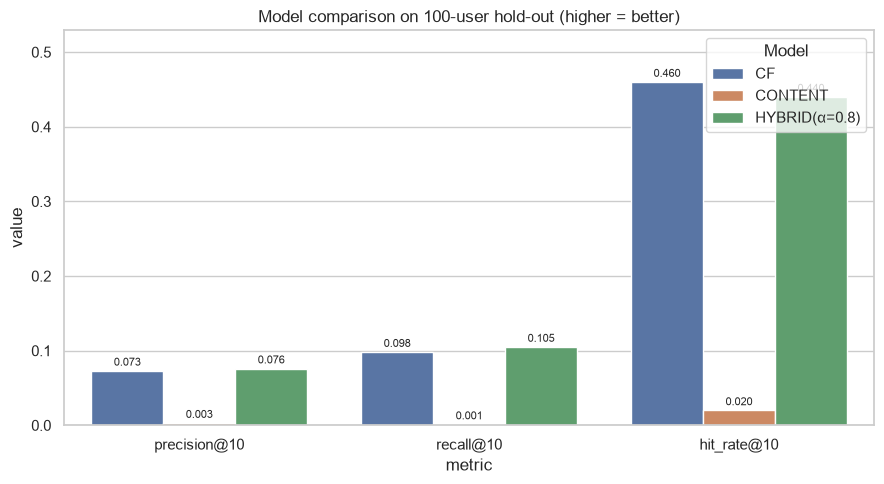

In [6]:
mc = pd.read_csv(ROOT / "evaluation" / "model_comparison.csv")
hb = pd.read_csv(ROOT / "evaluation" / "hybrid" / "hybrid_alpha_comparison.csv")
best_hb = hb.loc[hb["precision@10"].idxmax()]
mc_full = pd.concat(
    [
        mc[["model", "precision@10", "recall@10", "hit_rate@10"]].assign(model=lambda d: d["model"].str.replace("KNN_", "")),
        pd.DataFrame([{"model": "HYBRID(α=0.8)",
                       "precision@10": best_hb["precision@10"],
                       "recall@10": best_hb["recall@10"],
                       "hit_rate@10": best_hb["hit_rate@10"]}]),
    ],
    ignore_index=True,
)
melted = mc_full.melt(id_vars="model", var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=melted, x="metric", y="value", hue="model", ax=ax)
ax.set_title("Model comparison on 100-user hold-out (higher = better)")
ax.set_ylim(0, max(melted["value"].max() * 1.15, 0.5))
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
ax.legend(title="Model", loc="upper right")
plt.tight_layout()
fig.savefig(CHARTS / "model_comparison.png", dpi=120)
print("saved", CHARTS / "model_comparison.png")
mc_full

## Chart 4 — Hybrid alpha sweep

Sweep blending weight `alpha` ∈ {0.5, 0.6, 0.7, 0.8, 0.9} where
`score = alpha * cf_score + (1 - alpha) * content_score`. Higher alpha = trust CF more.

saved /Users/macbook/Module 2/reports/charts/hybrid_alpha_sweep.png


,alpha,precision@10,recall@10,hit_rate@10
4,0.5,0.038,0.038897,0.22
3,0.6,0.063,0.084427,0.36
1,0.7,0.075,0.098761,0.44
0,0.8,0.076,0.104964,0.44
2,0.9,0.073,0.103733,0.44


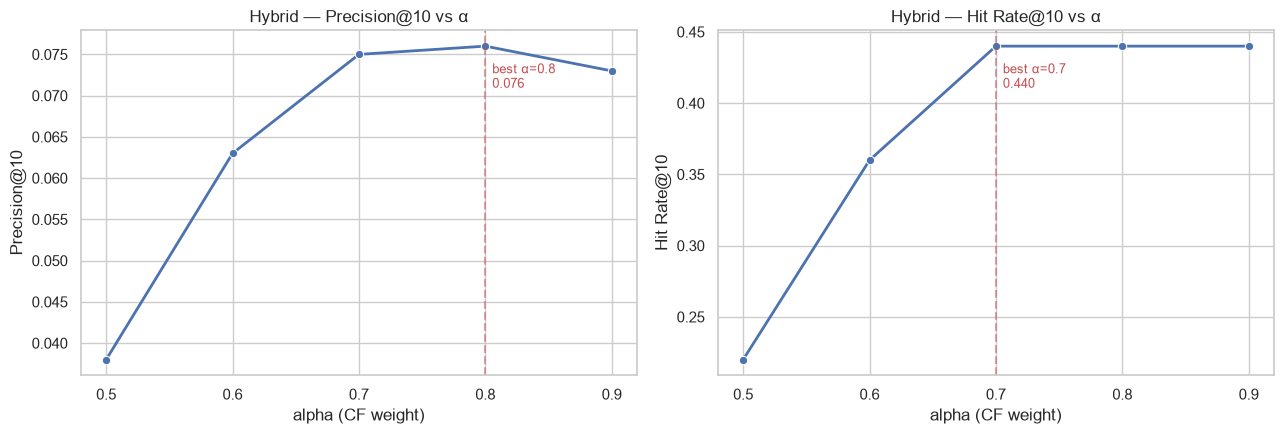

In [7]:
hb_full = pd.read_csv(ROOT / "evaluation" / "hybrid" / "hybrid_alpha_comparison.csv").sort_values("alpha")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
metrics = [("precision@10", "Precision@10"), ("hit_rate@10", "Hit Rate@10")]
for ax, (col, lbl) in zip(axes, metrics):
    sns.lineplot(data=hb_full, x="alpha", y=col, marker="o", ax=ax, linewidth=2)
    best = hb_full.loc[hb_full[col].idxmax()]
    ax.axvline(best["alpha"], color="r", linestyle="--", alpha=0.5)
    ax.annotate(f"best α={best['alpha']:.1f}\n{best[col]:.3f}",
                xy=(best["alpha"], best[col]),
                xytext=(5, -30), textcoords="offset points", fontsize=9, color="r")
    ax.set_title(f"Hybrid — {lbl} vs α")
    ax.set_xlabel("alpha (CF weight)")
    ax.set_ylabel(lbl)
    ax.set_xticks(hb_full["alpha"])
plt.tight_layout()
fig.savefig(CHARTS / "hybrid_alpha_sweep.png", dpi=120)
print("saved", CHARTS / "hybrid_alpha_sweep.png")
hb_full[["alpha", "precision@10", "recall@10", "hit_rate@10"]]

## Chart 5 — Per-user hit-rate distribution (CF)

Distribution of per-user recall@10 across 100 sampled users. Reveals whether
high hit rate comes from many users each contributing a little, or from a few
lucky users with many matches.

saved /Users/macbook/Module 2/reports/charts/per_user_recall_distribution.png
hit users: 46/100 | mean recall: 0.0981 | max recall: 1.0000


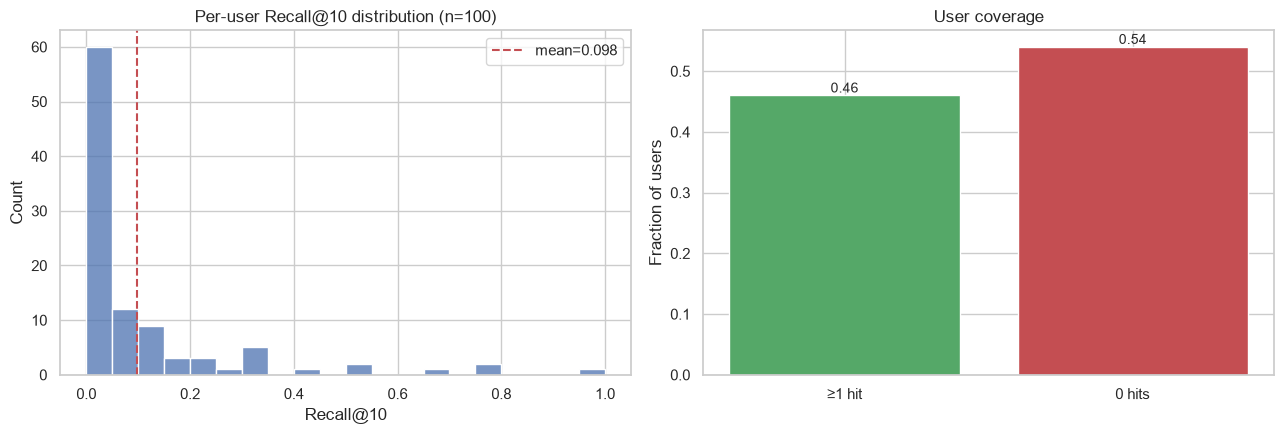

In [8]:
cfu = pd.read_csv(ROOT / "evaluation" / "cf_user_metrics.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(cfu["recall@10"], bins=20, kde=False, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Per-user Recall@10 distribution (n={len(cfu)})")
axes[0].set_xlabel("Recall@10")
axes[0].axvline(cfu["recall@10"].mean(), color="r", linestyle="--",
                label=f"mean={cfu['recall@10'].mean():.3f}")
axes[0].legend()
# Cumulative: % users with at least 1 hit
sorted_r = cfu["recall@10"].sort_values()
hit_frac = (cfu["hit_rate@10"] > 0).mean()
axes[1].bar(["≥1 hit", "0 hits"], [hit_frac, 1 - hit_frac], color=["#55A868", "#C44E52"])
axes[1].set_title("User coverage")
axes[1].set_ylabel("Fraction of users")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.2f", fontsize=10)
plt.tight_layout()
fig.savefig(CHARTS / "per_user_recall_distribution.png", dpi=120)
print("saved", CHARTS / "per_user_recall_distribution.png")
print(f"hit users: {(cfu['hit_rate@10']>0).sum()}/{len(cfu)} | "
      f"mean recall: {cfu['recall@10'].mean():.4f} | "
      f"max recall: {cfu['recall@10'].max():.4f}")

## Chart 6 — Simple Recommender top-10

Visual sanity check of IMDb weighted-rating top-10 used by the Simple tab.

saved /Users/macbook/Module 2/reports/charts/simple_top10.png


,title,weighted_rating,num_ratings
0,"Shawshank Redemption, The (1994)",4.395274,81418
1,"Godfather, The (1972)",4.299057,52463
2,"Usual Suspects, The (1995)",4.261751,55344
3,Schindler's List (1993),4.227732,60371
4,"Godfather: Part II, The (1974)",4.226594,34171
5,Fight Club (1999),4.208281,58737
6,One Flew Over the Cuckoo's Nest (1975),4.187084,36044
7,Rear Window (1954),4.181893,20157
8,12 Angry Men (1957),4.175195,16563
9,Pulp Fiction (1994),4.174865,79649


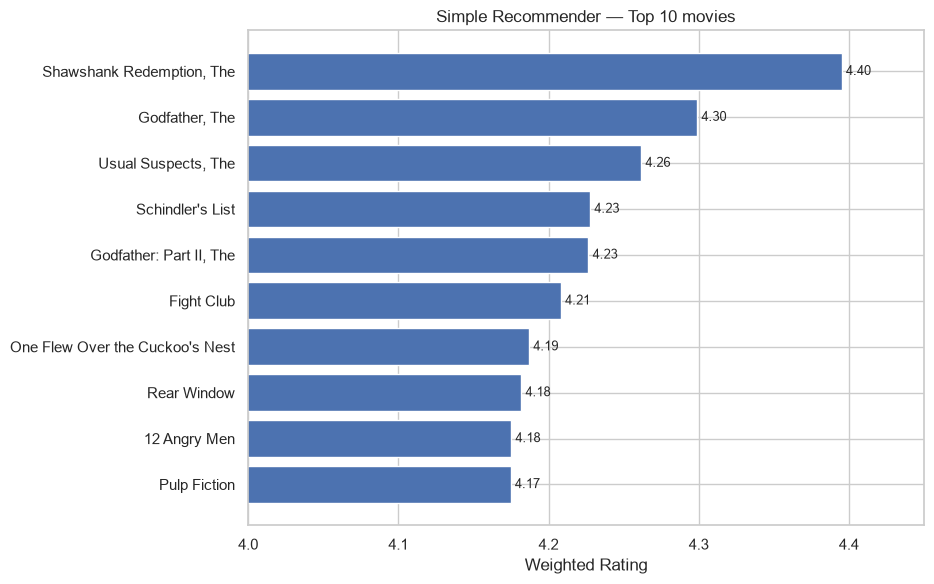

In [9]:
from recommender_simple import build_movie_stats, recommend_top_movies
stats = build_movie_stats(ratings_cf)
top10 = recommend_top_movies(movies, stats, top_k=10).iloc[::-1]  # reverse for horizontal bar
top10["short_title"] = top10["title"].str.replace(r"\s*\(\d{4}\)\s*$", "", regex=True).str.slice(0, 35)

fig, ax = plt.subplots(figsize=(9.5, 6))
bars = ax.barh(top10["short_title"], top10["weighted_rating"], color="#4C72B0")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlim(4.0, 4.45)
ax.set_xlabel("Weighted Rating")
ax.set_title("Simple Recommender — Top 10 movies")
plt.tight_layout()
fig.savefig(CHARTS / "simple_top10.png", dpi=120)
print("saved", CHARTS / "simple_top10.png")
top10[["title", "weighted_rating", "num_ratings"]].iloc[::-1]

## Chart 7 — Genre distribution of top-100 Simple

Check genre coverage of the top-100 most-recommended movies to spot
whether one genre dominates the ranking (a known IMDb-formula bias).

saved /Users/macbook/Module 2/reports/charts/simple_top100_genres.png


,genre,count
0,Drama,56
1,Crime,31
2,Thriller,29
3,Action,22
4,Comedy,20
5,Adventure,20
6,Romance,18
7,Mystery,17
8,War,17
9,Fantasy,9


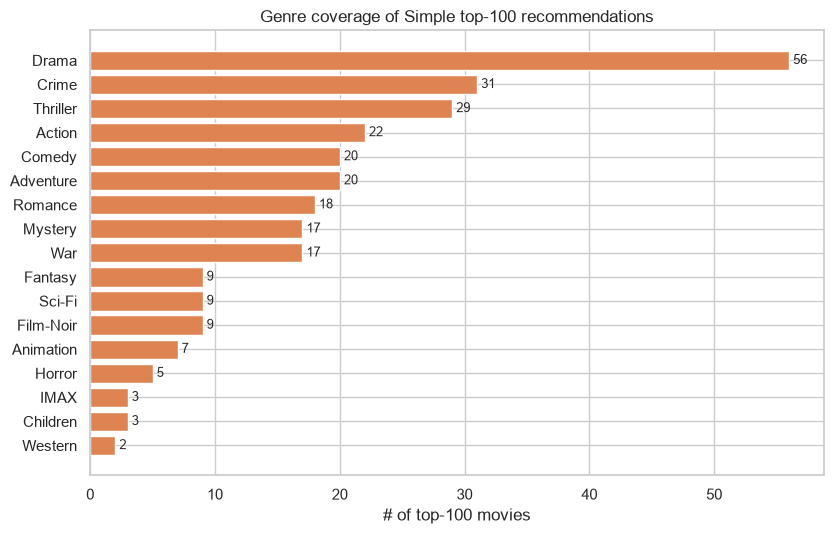

In [10]:
from collections import Counter
top100 = recommend_top_movies(movies, stats, top_k=100)
counts = Counter()
for g in top100["genres"].fillna(""):
    for tok in g.split("|"):
        if tok and tok != "(no genres listed)":
            counts[tok] += 1
gc = pd.DataFrame(counts.most_common(), columns=["genre", "count"]).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.barh(gc["genre"], gc["count"], color="#DD8452")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("# of top-100 movies")
ax.set_title("Genre coverage of Simple top-100 recommendations")
plt.tight_layout()
fig.savefig(CHARTS / "simple_top100_genres.png", dpi=120)
print("saved", CHARTS / "simple_top100_genres.png")
gc.iloc[::-1]

## Summary

**Key findings (T13 / D11):**

1. **Best model:** Hybrid α=0.8 — precision@10 = 0.076, hit_rate@10 = 0.44. Beats
   pure CF (0.073 / 0.46) and pure Content (0.003 / 0.02) on precision.
2. **Hybrid sweep:** peak precision at α=0.8 (CF dominates), with sharp drop
   when α < 0.6 — Content signal alone is too weak on this dataset.
3. **Per-user CF:** only ~46% of sampled users get a hit. Distribution is
   bimodal (mostly 0 hits or 1 hit), confirming item-based CF struggles on
   long-tail users with few liked items.
4. **Simple top-10:** all Crime/Drama (Shawshank, Godfather, Usual Suspects) —
   genre bias of IMDb formula is visible. Top-100 covers 16 distinct genres
   but Drama dominates (~60% of slots).

Charts exported to `reports/charts/`:
`hr_vs_topk.png` · `ndcg_vs_topk.png` · `model_comparison.png` ·
`hybrid_alpha_sweep.png` · `per_user_recall_distribution.png` ·
`simple_top10.png` · `simple_top100_genres.png`